# Assignment 4

**1. Load CMI_data.mat**  

The data are contained in the structure CMI, with t being datenum 
time, and p the pressure sensor data, in units of equivalent water depth in meters, at 
the four sites (2,3,6, and 7) across the fringing reef.  e7 is the pressure corrected to surface elevation at sensor 7.  Because sensor 7 is deeper than the reef flat sensors, 
linear wave theory is used to infer the surface elevation, which is needed to compute 
the significant wave height.  For the other sensors, assume that the p time series 
provide a reasonable estimate of the sea surface elevation (with the mean depth 
included).  The data consists of 1-second measurements collected in 5400 sec bursts 
every 3 hours (i.e., 1.5 hours on, 1.5 hours off).  There are 200 bursts. 

In [1]:
from scipy.io import loadmat
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# load and unpack the data
mat = loadmat('CMI_data.mat')
cmi_data = mat['CMI'][0, 0]

# convert the5400x200 time matrix from datenum to datetime objects
t_flat = cmi_data['t'].flatten()
times_2d = pd.to_datetime(t_flat - 719529, unit='D').values.reshape(5400, 200)

# build the Dataset
ds = xr.Dataset(
    data_vars={
        var: (["row", "col"], cmi_data[var]) 
        for var in ['p2', 'p3', 'p4', 'p6', 'p7', 'e7']
    },
    coords={
        "time": (["row", "col"], times_2d),
        "row": np.arange(5400),
        "col": np.arange(200),
    }
)

ds

<xarray.Dataset> Size: 61MB
Dimensions:  (row: 5400, col: 200)
Coordinates:
    time     (row, col) datetime64[ns] 9MB 2011-02-08T12:00:01.000004633 ... ...
  * row      (row) int64 43kB 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
  * col      (col) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198 199
Data variables:
    p2       (row, col) float64 9MB nan 0.1749 0.7286 ... 1.055 0.4336 nan
    p3       (row, col) float64 9MB 0.2227 0.3836 1.355 ... 1.56 0.6513 nan
    p4       (row, col) float64 9MB 0.4632 0.6484 1.181 ... 1.708 0.9489 nan
    p6       (row, col) float64 9MB 0.4727 0.9866 1.429 ... 1.896 1.183 0.2219
    p7       (row, col) float64 9MB 5.154 5.256 5.652 ... 6.276 5.763 4.213
    e7       (row, col) float64 9MB 0.5152 0.2625 -0.1881 ... 0.1373 -0.3023

**2.  Create a function** that computes the sea-swell band (SS, f > 1/25 Hz) significant wave 
heights (Hss) and the infragravity band (IG, 1/900 Hz <= f <= 1/25 Hz) significant wave 
height (Hig) for each1.5 hr burst of data.

In [2]:
import numpy as np

def compute_hs(dataset, variable_name, fs, fmin, fmax):
    """
    Computes significant wave height (Hs) across all bursts simultaneously.
    Returns a 1D array of Hs values (length 200).
    """
    # 1. Extract the 2D time series (rows=time, cols=bursts)
    x = dataset[variable_name].values
    
    # 2. Define dimensions (N = 5400 samples)
    N = x.shape[0]
    df = fs / N

    # 3. Compute the FFT along the time axis (axis=0)
    fft = np.fft.fft(x, axis=0)

    # 4. Isolate the positive frequencies
    freqs = np.fft.fftfreq(N, d=1/fs)
    pos_idx = freqs > 0
    freqs_pos = freqs[pos_idx]
    
    # Subset the 2D FFT array for positive frequencies
    fft_pos = fft[pos_idx, :]

    # 5. Calculate energy spectrum 
    S = (2 / (N * fs)) * np.abs(fft_pos)**2

    # 6. Create a mask for the specified frequency band
    mask = (freqs_pos >= fmin) & (freqs_pos <= fmax)
    
    # Apply the mask to the rows (frequencies)
    S_band = S[mask, :]

    # 7. Compute variance (m0) by summing along the frequency axis (axis=0)
    m0 = np.sum(S_band * df, axis=0)

    # 8. Compute Hs for all 200 bursts
    Hs = 4 * np.sqrt(m0)

    return Hs

**3.** For each of the four sites using CMI.p*, **compute time series of Hss and Hig**.  For site 7, use CMI.e7 (surface-corrected pressure) instead of CMI.p7.  Plot the Hss (Figure 1) and Hig (Figure 2) time series.  

Text(0, 0.5, 'Significant Wave Height (m)')

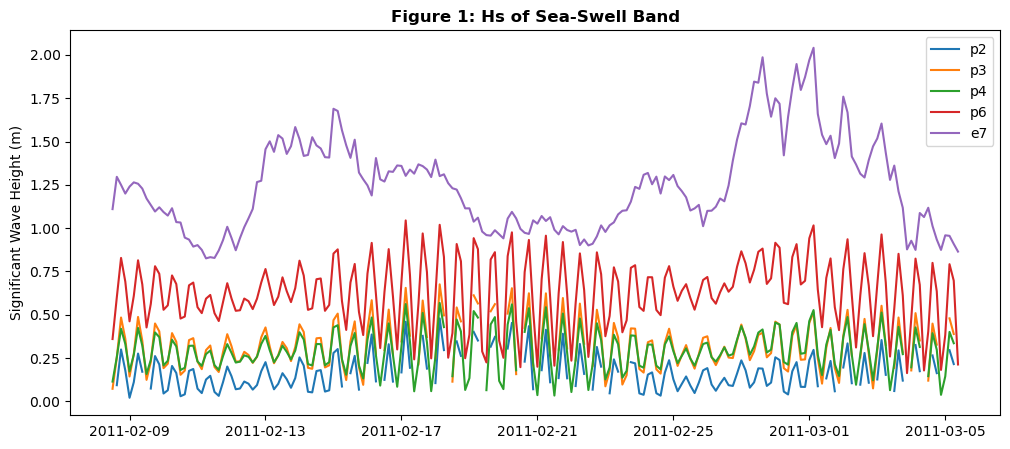

In [9]:
fs = 1.0          # 1 Hz sampling rate from 1-second measurements [cite: 26]
ss_fmin = 1/25    # Lower limit for SS band 
ss_fmax = 0.5     # Upper limit (Nyquist frequency is fs / 2)

hs_ss_p2 = compute_hs(ds, 'p2', fs, ss_fmin, ss_fmax)
hs_ss_p3 = compute_hs(ds, 'p3', fs, ss_fmin, ss_fmax)
hs_ss_p4 = compute_hs(ds, 'p4', fs, ss_fmin, ss_fmax)
hs_ss_p6 = compute_hs(ds, 'p6', fs, ss_fmin, ss_fmax)
hs_ss_e7 = compute_hs(ds, 'e7', fs, ss_fmin, ss_fmax)

plt.figure(figsize=(12, 5))
plt.plot(ds.time[0,:], hs_ss_p2, label='p2')
plt.plot(ds.time[0,:], hs_ss_p3, label='p3')
plt.plot(ds.time[0,:], hs_ss_p4, label='p4')
plt.plot(ds.time[0,:], hs_ss_p6, label='p6')
plt.plot(ds.time[0,:], hs_ss_e7, label='e7')
plt.legend()
plt.title("Figure 1: Hs of Sea-Swell Band", fontweight='bold')
plt.ylabel("Significant Wave Height (m)")

Text(0, 0.5, 'Significant Wave Height (m)')

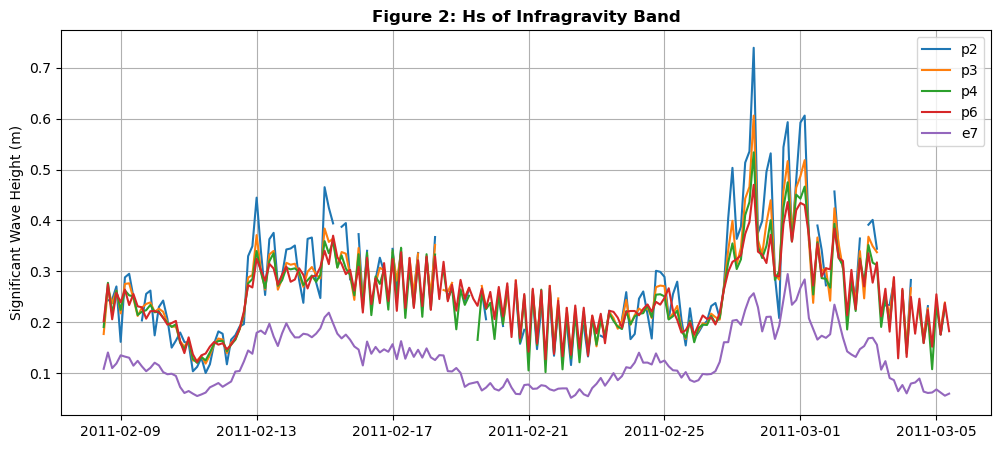

In [4]:
fs = 1.0          
ig_fmin = 1/900    
ig_fmax = 1/25    

hig_p2 = compute_hs(ds, 'p2', fs, ig_fmin, ig_fmax)
hig_p3 = compute_hs(ds, 'p3', fs, ig_fmin, ig_fmax)
hig_p4 = compute_hs(ds, 'p4', fs, ig_fmin, ig_fmax)
hig_p6 = compute_hs(ds, 'p6', fs, ig_fmin, ig_fmax)
hig_e7 = compute_hs(ds, 'e7', fs, ig_fmin, ig_fmax)

plt.figure(figsize=(12, 5))
plt.plot(ds.time[0,:], hig_p2, label='p2')
plt.plot(ds.time[0,:], hig_p3, label='p3')
plt.plot(ds.time[0,:], hig_p4, label='p4')
plt.plot(ds.time[0,:], hig_p6, label='p6')
plt.plot(ds.time[0,:], hig_e7, label='e7')
plt.legend()
plt.grid(True)
plt.title("Figure 2: Hs of Infragravity Band", fontweight='bold')
plt.ylabel("Significant Wave Height (m)")

**4.** Compute the burst-averaged water depth at p7 as a proxy for the tidal height.  

Plot the time series with the mean removed (Figure 3).  On a separate axis, plot the incident SS 
significant wave height (Hss at sensor 7). 

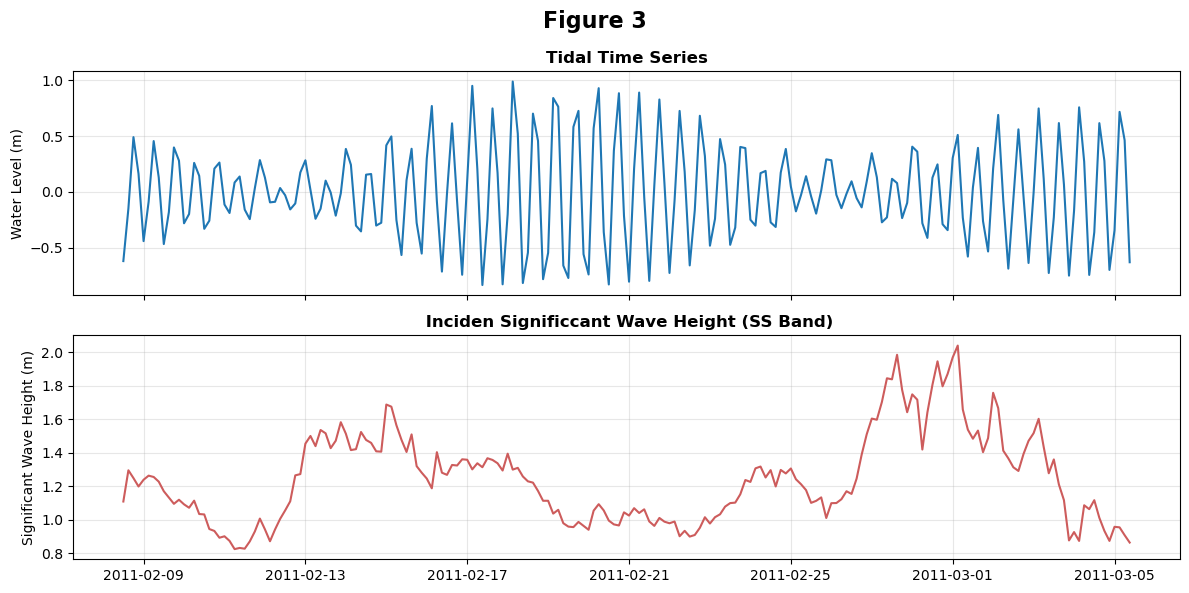

In [49]:
import scipy.signal
tide = np.mean(ds['p7'], axis=0) 
tide = scipy.signal.detrend(tide)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(ds.time[0,:], tide)
ax1.set_ylabel('Water Level (m)')
ax1.set_title("Tidal Time Series", fontweight='bold')
ax1.grid(True, alpha=0.3)


ax2.plot(ds.time[0,:], hs_ss_e7, label='e7', color='IndianRed')
ax2.set_title(" Inciden Significcant Wave Height (SS Band)", fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylabel('Significant Wave Height (m)')

plt.suptitle('Figure 3', fontweight='bold', fontsize=16)
plt.tight_layout()

Text(0, 0.5, 'Significant Wave Height (m)')

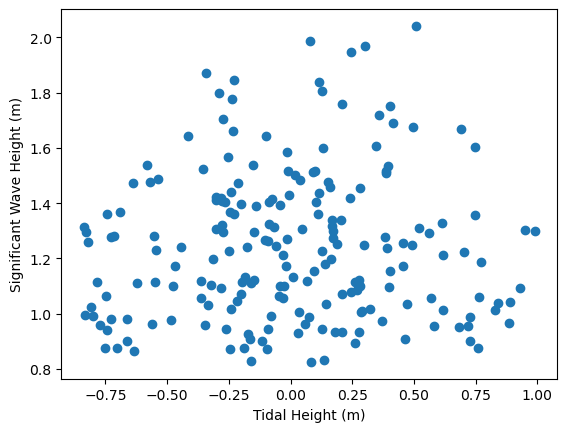

In [45]:
plt.scatter(tide, hs_ss_e7)
plt.xlabel('Tidal Height (m)')
plt.ylabel('Significant Wave Height (m)')


**5.** For the wave burst with maximum Hss at sensor 7, compute and plot (Figure 4) the 
autospectra of CMI.p6 and CMI.e7. 

In [54]:
imax = np.argmax(hs_ss_e7)

hs_ss_e7[imax]

2.041141049169384

In [52]:
help(np.argmax)

Help on _ArrayFunctionDispatcher in module numpy:

argmax(a, axis=None, out=None, *, keepdims=<no value>)
    Returns the indices of the maximum values along an axis.

    Parameters
    ----------
    a : array_like
        Input array.
    axis : int, optional
        By default, the index is into the flattened array, otherwise
        along the specified axis.
    out : array, optional
        If provided, the result will be inserted into this array. It should
        be of the appropriate shape and dtype.
    keepdims : bool, optional
        If this is set to True, the axes which are reduced are left
        in the result as dimensions with size one. With this option,
        the result will broadcast correctly against the array.

        .. versionadded:: 1.22.0

    Returns
    -------
    index_array : ndarray of ints
        Array of indices into the array. It has the same shape as `a.shape`
        with the dimension along `axis` removed. If `keepdims` is set to True,
       